Exploring and modelling the CIFAR dataset over here.. let's see how it goes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [3]:
from tensorflow.keras.datasets import cifar10

train, test= cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2165s 13us/step


In [15]:
train[0].shape, train[1].shape

((50000, 32, 32, 3), (50000, 1))

As mentioned by the author in the documentation for CIFAR 10..

Each of the batch files contains a dictionary with the following elements:    
**data** -- a 10000x3072 numpy array of uint8s. Each row of the array stores a 32x32 colour image. The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image.   
**labels** -- a list of 10000 numbers in the range 0-9. The number at index i indicates the label of the ith image in the array data.

First and foremost, we seperate our train, validation and test sets

In [17]:
X_train, y_train = train[0][:40000], train[1][:40000]
X_valid, y_valid = train[0][40000:], train[1][40000:]
X_test, y_test= test[0], test[1]

In [18]:
X_train.shape

(40000, 32, 32, 3)

In [20]:
X_valid.shape

(10000, 32, 32, 3)

In [21]:
X_test.shape

(10000, 32, 32, 3)

Perhaps, we might be giving away a little too much data away for validation, but let's see where it goes

In [24]:
X_train[0].shape ## this is the shape of one image

(32, 32, 3)

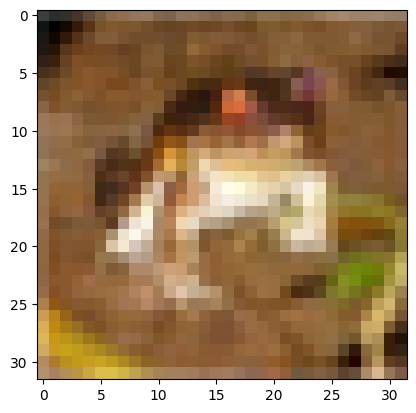

In [28]:
plt.imshow(X_train[0])

Even for a human, this sort of a pixelated image is tough to identify

In [54]:
# This list has been given to us in the documentation for reference
labels = np.array([
    "airplane","automobile","bird","cat",
    "deer","dog","frog","horse","ship","truck"
])

Let's see what it is

In [55]:
y_train[0]

array([6], dtype=uint8)

In [56]:
labels[y_train[0]]

array(['frog'], dtype='<U10')

Well... that was a frog.. but are all pictures going to be like this?

In [63]:
labels[y_train[0]][0]

'frog'

In [49]:
#Scaling the 0-255 values down to 0-1

X_train, X_valid, X_test= X_train/255, X_valid/255, X_test/255

In [52]:
X_train[0][:,1][:5]

array([[0.16862745, 0.18039216, 0.17647059],
       [0.        , 0.        , 0.        ],
       [0.0627451 , 0.02745098, 0.        ],
       [0.14901961, 0.07843137, 0.01568627],
       [0.23137255, 0.1254902 , 0.04313725]])

In [69]:
indices= np.random.choice(40000, 40, replace= False)
indices

array([22403,   130,  6073, 16314, 28336, 37868, 35230, 29306, 24628,
        7344,  3641, 12296, 22435,  9725, 32674,  5014, 22316, 21372,
       15084, 22442, 25768, 17418, 32309,  2858,  8484,  1377,  5431,
        8723, 15019,  9433, 35712, 17087,   931, 16073,   463,  4924,
       20732, 15900, 32181, 19687])

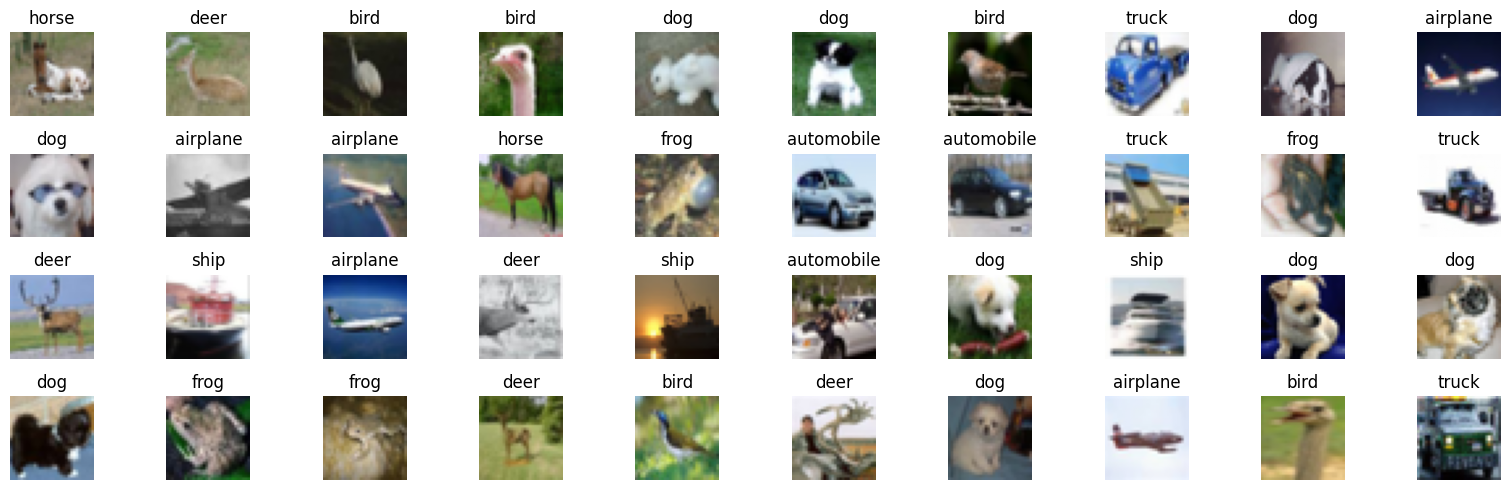

In [70]:
fig, axes= plt.subplots(4,10, figsize= (16,5))

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(labels[y_train[i]][0])
    ax.axis("off")

plt.tight_layout()

Okay, so not all, but definitely some are tough to identify

Looking, at the documentation,   
"You can find some baseline replicable results on this dataset on the project page for cuda-convnet. These results were obtained with a convolutional neural network. Briefly, they are 18% test error without data augmentation and 11% with." 

So if with a CNN, were reaching 18%... let's put a target of 20 with NN first. 

Starting with a basic model, we'll go with a **X (Input)-> 100 -> 80 -> 40 -> 20 -> 10 (Output)**  Neural Network

In [82]:
model1= tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= [32,32, 3]), 
    tf.keras.layers.Dense(100, activation= "relu"), 
    tf.keras.layers.Dense(80, activation= "relu"), 
    tf.keras.layers.Dense(40, activation= "relu"), 
    tf.keras.layers.Dense(20, activation= "relu"), 
    tf.keras.layers.Dense(10, activation= "softmax"), 
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [83]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │         307,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 80)                  │           8,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 40)                  │           3,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 20)                  │             820 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 319,650 (1.22 MB)

 Trainable params: 319,650 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model1.layers[1].get_weights()

[array([[ 0.03425473, -0.00221491,  0.04108424, ..., -0.00748685,
          0.03577712, -0.04212715],
        [-0.00108334,  0.0210521 , -0.00617195, ...,  0.03545287,
         -0.00141396,  0.03626599],
        [ 0.03756849, -0.04274095,  0.01831373, ..., -0.03020609,
         -0.04132382,  0.04095097],
        ...,
        [ 0.03328329,  0.00580244, -0.03095792, ..., -0.01198326,
         -0.04294561, -0.01730695],
        [-0.01229992,  0.00232635,  0.01503311, ..., -0.01318119,
         -0.00043231, -0.02999128],
        [-0.00506483,  0.0139627 ,  0.0042979 , ..., -0.02017268,
          0.02690961,  0.00381912]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [85]:
model1.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "sgd", 
              metrics = ["accuracy"])

In [86]:
history = model1.fit(X_train, y_train, epochs= 50, 
                   validation_data= (X_valid, y_valid))

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1983 - loss: 2.1364 - val_accuracy: 0.3180 - val_loss: 1.8878
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3340 - loss: 1.8432 - val_accuracy: 0.3297 - val_loss: 1.8723
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3590 - loss: 1.7707 - val_accuracy: 0.3586 - val_loss: 1.7597
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3870 - loss: 1.6961 - val_accuracy: 0.4006 - val_loss: 1.6643
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4078 - loss: 1.6471 - val_accuracy: 0.4047 - val_loss: 1.6515
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4258 - loss: 1.6018 - val_accuracy: 0.4037 - val_loss: 1.7018
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4358 - loss: 1.5671 - val_accuracy: 0.4467 - val_loss: 1.5666
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4509 - loss: 1.5332 - 

In [87]:
history.params

{'verbose': 'auto', 'epochs': 50, 'steps': 1250}

In [88]:
history.history

{'accuracy': [0.25452500581741333,
  0.3385249972343445,
  0.3656750023365021,
  0.3893499970436096,
  0.411175012588501,
  0.4286249876022339,
  0.4364500045776367,
  0.45122501254081726,
  0.46105000376701355,
  0.46779999136924744,
  0.47760000824928284,
  0.48672500252723694,
  0.4886249899864197,
  0.49582499265670776,
  0.5037999749183655,
  0.5067750215530396,
  0.5128250122070312,
  0.5199750065803528,
  0.5247250199317932,
  0.52920001745224,
  0.5347499847412109,
  0.5392000079154968,
  0.543749988079071,
  0.5493999719619751,
  0.5521500110626221,
  0.5561500191688538,
  0.5604749917984009,
  0.5648999810218811,
  0.5671749711036682,
  0.5710999965667725,
  0.5747500061988831,
  0.58017498254776,
  0.5807499885559082,
  0.5870000123977661,
  0.59027498960495,
  0.5932250022888184,
  0.5944749712944031,
  0.5973749756813049,
  0.6018750071525574,
  0.6035749912261963,
  0.6082249879837036,
  0.6083750128746033,
  0.612375020980835,
  0.612375020980835,
  0.6176750063896179,
 

<Axes: xlabel='Epochs'>

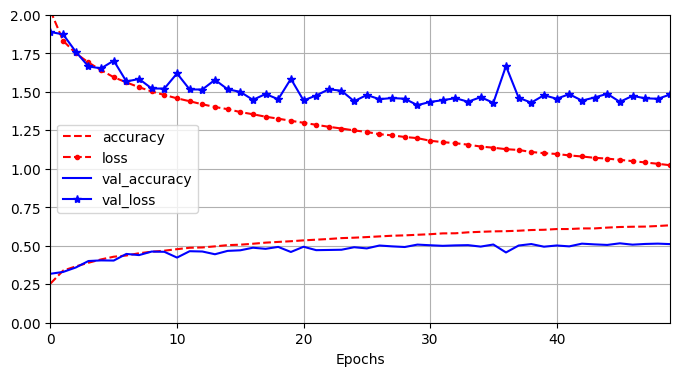

In [90]:
pd.DataFrame(history.history).plot(
    figsize= (8,4), xlim= [0,49], ylim= [0,2], grid= True, xlabel= "Epochs",
    style= ["r--", "r--.", "b-", "b-*"]
)

Hmmm.... Losses are diverging and we are at 0.65 accuracy with training but stagnating at 0.5 for validation

Maybe, Dropout might help us out.. We seem to be overfitting rn *a lil bit*, but also we need to make our model more complicated, right now, 0.5 or even 0.65 in training is off

In [115]:
model2= tf.keras.Sequential([ ## With Dropout
    tf.keras.layers.Flatten(input_shape= [32,32, 3]),
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(300, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(150, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(80, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05),
    tf.keras.layers.Dense(20, activation= "relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(10, activation= "softmax"), 
])

In [116]:
model2.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "adam", ## Let's switch to adam as well
              metrics = ["accuracy"])

In [117]:
history = model2.fit(X_train, y_train, epochs= 50, 
                   validation_data= (X_valid, y_valid))

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1508 - loss: 2.2174 - val_accuracy: 0.2566 - val_loss: 1.9870
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2549 - loss: 1.9678 - val_accuracy: 0.3048 - val_loss: 1.8826
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.2950 - loss: 1.8882 - val_accuracy: 0.3137 - val_loss: 1.8515
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3270 - loss: 1.8422 - val_accuracy: 0.3404 - val_loss: 1.8028
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3307 - loss: 1.8244 - val_accuracy: 0.3651 - val_loss: 1.7635
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3494 - loss: 1.7898 - val_accuracy: 0.3830 - val_loss: 1.7233
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3541 - loss: 1.7712 - val_accuracy: 0.3656 - val_loss: 1.7486
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3621 - loss: 1

<Axes: xlabel='Epochs'>

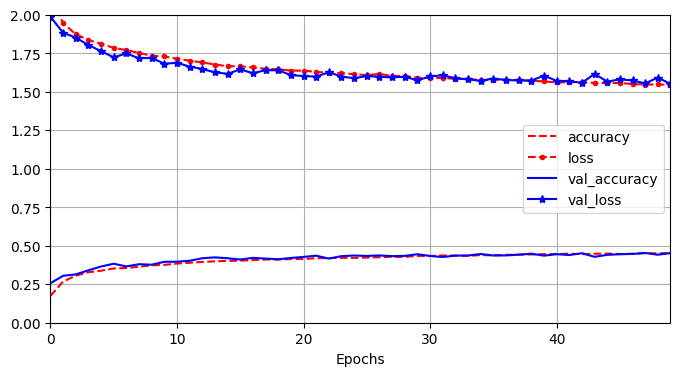

In [118]:
pd.DataFrame(history.history).plot(
    figsize= (8,4), xlim= [0,49], ylim= [0,2], grid= True, xlabel= "Epochs",
    style= ["r--", "r--.", "b-", "b-*"]
)

Dropout has clearly shown to be good enough to stop the difference between training and validation error but our model is simply not complex enough yet.. Let's see a version where it is longer but narrower

Perhaps.. we'll be better off, only applying dropout at the earlier layers?

In [119]:
model3= tf.keras.Sequential([ ## With Dropout
    tf.keras.layers.Flatten(input_shape= [32,32, 3]),
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(300, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.05), 
    tf.keras.layers.Dense(150, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.03), 
    tf.keras.layers.Dense(80, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dropout(rate= 0.02), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
    tf.keras.layers.Dense(20, activation= "relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(10, activation= "softmax"), 
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [120]:
model3.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "adam", ## Let's switch to adam as well
              metrics = ["accuracy"])

In [121]:
history = model3.fit(X_train, y_train, epochs= 50, 
                   validation_data= (X_valid, y_valid))

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1643 - loss: 2.2038 - val_accuracy: 0.3038 - val_loss: 1.8957
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3018 - loss: 1.8908 - val_accuracy: 0.3544 - val_loss: 1.7861
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3367 - loss: 1.8080 - val_accuracy: 0.3622 - val_loss: 1.7546
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3690 - loss: 1.7498 - val_accuracy: 0.3718 - val_loss: 1.7177
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3796 - loss: 1.7103 - val_accuracy: 0.3947 - val_loss: 1.6703
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3982 - loss: 1.6635 - val_accuracy: 0.3965 - val_loss: 1.6804
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4078 - loss: 1.6407 - val_accuracy: 0.4022 - val_loss: 1.6493
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4151 - loss: 1